



## **Question 1: What is Boosting in Machine Learning? Explain how it improves weak learners.**

**Answer:**

* Boosting is an ensemble learning technique that combines multiple weak learners to create a strong model.
* Weak learners are models that perform slightly better than random guessing.
* Models are trained sequentially, not independently.
* Misclassified data points are given more importance in subsequent models.
* Final prediction is a weighted combination of all learners.
* Boosting reduces bias and improves overall accuracy.

---

## **Question 2: What is the difference between AdaBoost and Gradient Boosting in terms of how models are trained?**

**Answer:**

* **AdaBoost:**

  * Increases weights of misclassified samples.
  * Uses exponential loss function.
  * Highly sensitive to noisy data and outliers.
  * Focuses directly on incorrectly predicted instances.

* **Gradient Boosting:**

  * Trains models on residual errors of previous models.
  * Uses gradient descent to minimize loss.
  * Supports different loss functions.
  * More flexible and robust than AdaBoost.

---

## **Question 3: How does regularization help in XGBoost?**

**Answer:**

* Prevents overfitting by penalizing complex models.
* Controls tree depth and leaf weights.
* Uses **L1 regularization (alpha)** to reduce irrelevant features.
* Uses **L2 regularization (lambda)** to smooth model weights.
* Improves model generalization on unseen data.

---

## **Question 4: Why is CatBoost efficient for handling categorical data?**

**Answer:**

* Handles categorical features directly without manual encoding.
* Uses ordered target encoding to avoid data leakage.
* Automatically manages missing values.
* Reduces overfitting caused by one-hot encoding.
* Provides high accuracy with minimal preprocessing.

---

## **Question 5:What are some real-world applications where boosting techniques are preferred over bagging methods?**

**Answer:**

* Credit scoring and loan default prediction.
* Fraud detection systems.
* Medical diagnosis and disease prediction.
* Customer churn prediction.
* Search engine ranking systems.
* Advertising click-through rate prediction.



---

In [13]:
"""Datasets:
● Use sklearn.datasets.load_breast_cancer() for classification tasks.
● Use sklearn.datasets.fetch_california_housing() for regression
tasks.

Question 6: Write a Python program to:
● Train an AdaBoost Classifier on the Breast Cancer dataset
● Print the model accuracy
(Include your Python code and output in the code box below.)
"""

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score

# Load the Breast Cancer dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train the AdaBoost Classifier
ada = AdaBoostClassifier(n_estimators=100, random_state=42)
ada.fit(X_train, y_train)

# Make predictions
y_pred = ada.predict(X_test)

# Calculate and print accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)



Model Accuracy: 0.9736842105263158


In [2]:
"""
Question 7: Write a Python program to:
● Train a Gradient Boosting Regressor on the California Housing dataset
● Evaluate performance using R-squared score
(Include your Python code and output in the code box below
"""
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score

# Load the California Housing dataset
data = fetch_california_housing()
X = data.data
y = data.target

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train the Gradient Boosting Regressor
gbr = GradientBoostingRegressor(random_state=42)
gbr.fit(X_train, y_train)

# Make predictions
y_pred = gbr.predict(X_test)

# Calculate and print R-squared score
r2 = r2_score(y_test, y_pred)
print("R-squared Score:", r2)


R-squared Score: 0.7756446042829697


In [21]:
"""
Question 8: Write a Python program to:
● Train an XGBoost Classifier on the Breast Cancer dataset
● Tune the learning rate using GridSearchCV
● Print the best parameters and accuracy
(Include your Python code and output in the code box below.)

"""
# Import required libraries
from xgboost import XGBClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score

# Load Breast Cancer dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Initialize XGBoost Classifier
xgb = XGBClassifier(
    eval_metric="logloss",
    random_state=42
)

# Hyperparameter grid (learning rate)
param_grid = {
    "learning_rate": [0.01, 0.05, 0.1, 0.2]
}

# Apply GridSearchCV
grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train, y_train)

# Best model
best_model = grid.best_estimator_

# Predictions
y_pred = best_model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

# Print results
print("Best Parameters:", grid.best_params_)
print("Accuracy:", accuracy)



Best Parameters: {'learning_rate': 0.2}
Accuracy: 0.956140350877193


Accuracy: 0.9736842105263158


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127752 (\N{RAINBOW}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


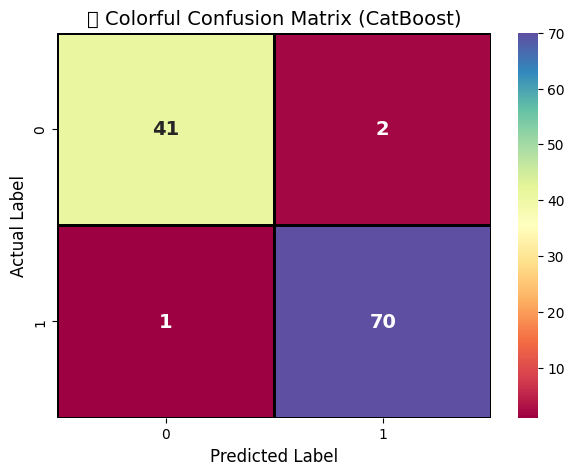

In [19]:
"""Question 9: Write a Python program to:
● Train a CatBoost Classifier
● Plot the confusion matrix using seaborn
(Include your Python code and output in the code box below.)
"""
# Import required libraries
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from catboost import CatBoostClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train CatBoost Classifier
model = CatBoostClassifier(verbose=0)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

#  Colorful Confusion Matrix Plot
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Spectral",     # Colorful theme
    cbar=True,
    linewidths=2,
    linecolor="black",
    annot_kws={"size": 14, "weight": "bold"}
)

plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("Actual Label", fontsize=12)
plt.title("🌈 Colorful Confusion Matrix (CatBoost)", fontsize=14)
plt.show()




---

## **Question 10:**

You're working for a FinTech company trying to predict loan default using customer demographics and transaction behavior.
The dataset is imbalanced, contains missing values, and has both numeric and categorical features.

Describe your step-by-step data science pipeline using boosting techniques:

* Data preprocessing & handling missing/categorical values
* Choice between AdaBoost, XGBoost, or CatBoost
* Hyperparameter tuning strategy
* Evaluation metrics you'd choose and why
* How the business would benefit from your model

**Answer:**

### **Step 1: Data Preprocessing**

* Handle missing values:

  * Numerical columns → replace with median.
  * Categorical columns → replace with mode or use CatBoost internal handling.
* Encode categorical features:

  * Use CatBoost’s native categorical feature handling (no one-hot needed).
* Handle imbalanced classes:

  * Use **class weights** in CatBoost or apply **SMOTE** for oversampling minority class.
* Split dataset into training and test sets.

---

### **Step 2: Model Choice**

* **CatBoost** is preferred because:

  * Handles categorical variables directly.
  * Handles missing values internally.
  * Robust to class imbalance with `class_weights`.

---

### **Step 3: Hyperparameter Tuning**

* Use **GridSearchCV or RandomizedSearchCV**.
* Tune parameters such as:

  * `learning_rate`: 0.01, 0.05, 0.1
  * `depth`: 4, 6, 8
  * `iterations`: 100, 200, 500
* Optionally use **early stopping** to prevent overfitting.

---

### **Step 4: Evaluation Metrics**

* **ROC-AUC** → measures model’s ability to separate defaulters vs non-defaulters.
* **Recall (Sensitivity)** → important to minimize false negatives (missing potential defaulters).
* **F1-score** → balances precision and recall in imbalanced datasets.

---

### **Step 5: Business Benefits**

* Accurately predicts loan defaults → reduces financial losses.
* Improves risk assessment → better lending decisions.
* Optimizes capital allocation → focus on low-risk customers.
* Helps meet regulatory compliance for risk management.

---



In [22]:
# Import libraries
import pandas as pd
import numpy as np

from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score

# -------------------------------
# 1. Create sample FinTech dataset
# -------------------------------
data = {
    "Age": [25, 45, 35, np.nan, 50, 23, 40, 60, np.nan, 30],
    "Income": [50000, 80000, 60000, 75000, np.nan, 30000, 90000, 120000, 40000, np.nan],
    "Gender": ["M", "F", "F", "M", "F", "M", np.nan, "F", "M", "F"],
    "Employment_Type": ["Salaried", "Business", "Salaried", "Salaried",
                        "Business", "Student", "Salaried", "Business", "Student", np.nan],
    "Loan_Amount": [200000, 500000, 300000, 400000, 600000,
                     150000, 700000, 800000, 180000, 250000],
    "Default": [0, 1, 0, 0, 1, 0, 1, 1, 0, 0]
}

df = pd.DataFrame(data)

# ----------------------------------------
# 2. Handle missing values
# ----------------------------------------
# Numeric → median
for col in ["Age", "Income"]:
    df[col] = df[col].fillna(df[col].median())

# Categorical → "Unknown"
for col in ["Gender", "Employment_Type"]:
    df[col] = df[col].fillna("Unknown")

# ----------------------------------------
# 3. Split features and target
# ----------------------------------------
X = df.drop("Default", axis=1)
y = df["Default"]

cat_features = ["Gender", "Employment_Type"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# ----------------------------------------
# 4. Hyperparameter tuning with GridSearch
# ----------------------------------------
model = CatBoostClassifier(
    eval_metric="AUC",
    verbose=0,
    class_weights=[1, 3]   # handle imbalance
)

param_grid = {
    "depth": [4, 6],
    "learning_rate": [0.05, 0.1],
    "iterations": [100, 200]
}

grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=3
)

grid.fit(X_train, y_train, cat_features=cat_features)

best_model = grid.best_estimator_

# ----------------------------------------
# 5. Evaluation
# ----------------------------------------
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print("Best Parameters:", grid.best_params_)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))


Best Parameters: {'depth': 4, 'iterations': 100, 'learning_rate': 0.05}

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3

ROC-AUC Score: 1.0
